# Checkpoint 2 – Parte 1: Classificação da Estabilidade da Rede Elétrica

Modelo de **Regressão Logística** para prever se a rede elétrica é **estável** ou **instável** (coluna `stabf`),
usando o dataset *Electrical Grid Stability Simulated Data* (UCI).

- **Target (y):** `stabf` → classes `stable` / `unstable`
- **Features (X):** as 12 variáveis numéricas `tau1–tau4`, `p1–p4`, `g1–g4`
- A coluna `stab` **não** entra em X: ela é o valor numérico que dá origem a `stabf` (stab < 0 → estável), então usá-la seria "entregar a resposta" ao modelo (*data leakage*).

## Identificação do grupo

| Nome completo | RM |
|---|---|
| _preencher_ | _preencher_ |
| _preencher_ | _preencher_ |
| _preencher_ | _preencher_ |

## 1. Preparação do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

## 2. Carregamento e análise inicial

In [2]:
# Lê o CSV da pasta dados/ do repositório; no Colab (sem a pasta), baixa do GitHub do grupo
import os
caminho_local = '../dados/Data_for_UCI_named.csv'
url = 'https://raw.githubusercontent.com/denizeferrante/MachineLearning_DadosEnergia/refs/heads/main/dados/Data_for_UCI_named.csv'
dados = pd.read_csv(caminho_local if os.path.exists(caminho_local) else url)
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [3]:
print("Linhas e colunas:", dados.shape)
dados.info()

Linhas e colunas: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


In [4]:
print("Valores ausentes:", dados.isnull().sum().sum())
dados.describe()

Valores ausentes: 0


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [5]:
# Distribuição das classes
print(dados['stabf'].value_counts())
print()
print((dados['stabf'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')

stabf
unstable    6380
stable      3620
Name: count, dtype: int64

stabf
unstable    63.8 %
stable      36.2 %
Name: proportion, dtype: str


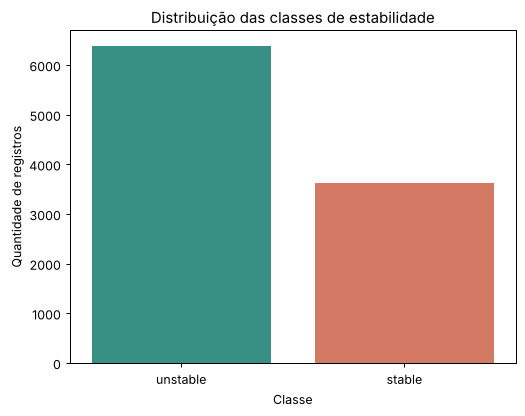

In [6]:
sns.countplot(data=dados, x='stabf', hue='stabf', palette=['#2a9d8f', '#e76f51'], legend=False)
plt.title('Distribuição das classes de estabilidade')
plt.xlabel('Classe'); plt.ylabel('Quantidade de registros')
plt.show()

**Observações:** o dataset tem 10.000 registros e 14 colunas, sem valores ausentes.
As classes são **desbalanceadas**: cerca de 64% dos registros são `unstable` e 36% `stable`.
Por isso, além da acurácia, vamos olhar precisão, recall e F1 de cada classe.

## 3. Definição de X (features) e y (target)

In [7]:
X = dados.drop(['stab', 'stabf'], axis=1)   # 12 features numéricas
y = dados['stabf']                          # target categórico
print('Features:', list(X.columns))
X.head()

Features: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


## 4. Separação em treino (80%) e teste (20%)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Treino:', X_train.shape[0], 'registros')
print('Teste :', X_test.shape[0], 'registros')

Treino: 8000 registros
Teste : 2000 registros


## 5. Treinamento do modelo de Regressão Logística

In [9]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## 6. Geração das previsões

In [10]:
probabilidades = modelo.predict_proba(X_test)
print('Ordem das classes:', modelo.classes_)
print(probabilidades[:5].round(3))

Ordem das classes: ['stable' 'unstable']
[[0.046 0.954]
 [0.061 0.939]
 [0.317 0.683]
 [0.978 0.022]
 [0.645 0.355]]


In [11]:
y_predict = modelo.predict(X_test)
pd.DataFrame({'Real': y_test.values[:10], 'Previsto': y_predict[:10]})

,Real,Previsto
0,unstable,unstable
1,unstable,unstable
2,unstable,unstable
3,stable,stable
4,stable,stable
5,unstable,stable
6,stable,stable
7,unstable,unstable
8,unstable,unstable
9,stable,stable


## 7. Avaliação: métricas de classificação

In [12]:
acuracia = accuracy_score(y_test, y_predict)
print(f'Acurácia: {acuracia*100:.2f}%')
print()
print(classification_report(y_test, y_predict, digits=4))

Acurácia: 81.70%

              precision    recall  f1-score   support

      stable     0.7437    0.7201    0.7317       693
    unstable     0.8540    0.8684    0.8612      1307

    accuracy                         0.8170      2000
   macro avg     0.7988    0.7942    0.7964      2000
weighted avg     0.8158    0.8170    0.8163      2000



## 8. Matriz de confusão

Estáveis previstos corretamente : 499
Estáveis previstos como instáveis: 194
Instáveis previstos como estáveis: 172
Instáveis previstos corretamente : 1135


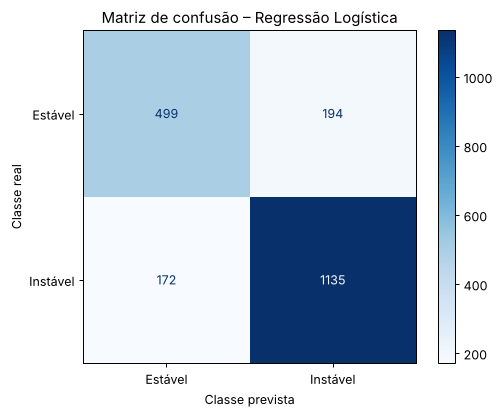

In [13]:
classes = ['stable', 'unstable']
matriz = confusion_matrix(y_test, y_predict, labels=classes)
ConfusionMatrixDisplay(matriz, display_labels=['Estável', 'Instável']).plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusão – Regressão Logística')
plt.xlabel('Classe prevista'); plt.ylabel('Classe real')
plt.show()

vp_est, fn_est, fp_est, vp_inst = matriz.ravel()
print(f'Estáveis previstos corretamente : {vp_est}')
print(f'Estáveis previstos como instáveis: {fn_est}')
print(f'Instáveis previstos como estáveis: {fp_est}')
print(f'Instáveis previstos corretamente : {vp_inst}')

## 9. Análise dos resultados

- **Acurácia de 81,70%**: o modelo acerta a condição da rede em cerca de 8 a cada 10 casos do conjunto de teste (2.000 registros).
- **Classe `unstable`** (majoritária): precisão ≈ 0,85 e recall ≈ 0,87 — o modelo identifica bem as redes instáveis.
- **Classe `stable`** (minoritária): precisão ≈ 0,74 e recall ≈ 0,72 — desempenho mais fraco; 194 redes estáveis foram classificadas como instáveis.
- **Erro mais crítico:** os **172 casos instáveis previstos como estáveis**. Na prática, esse é o erro mais perigoso, pois a rede seria considerada segura quando não está.
- **Limitação:** a Regressão Logística traça uma fronteira de decisão linear, e a relação entre as variáveis e a estabilidade não é totalmente linear. Por isso a acurácia fica em torno de 82%; modelos não lineares ou a padronização das features poderiam ser testados em etapas futuras.